# DoWhy Library
DoWhy is a Python library for causal inference that provides an end-to-end workflow for formulating and answering causal questions from data

- Focuses on making causal assumptions explicit using Causal Graphs and then checking how robust your conclusions are to violations of those assumptions
- It unifies two major causal frameworks under single interface
    - Graphic Causal Model (Pearl)
    - Potential Outcomes (Rubin)

## Four-Step Workflow
- Model: specify a causal graph  over your variables to encode prior knowledge and assumptions
- Identify: automatically derive an estimand (target) from the graph
- Estimate: apply a chosen estimator
- Refute: run robustness checks to test sensitivity of results

## Setup and Data

In [1]:
%pip install dowhy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 15.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [dowhy]32m8/9 [dowhy]-learn]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from dowhy import CausalModel
import dowhy.datasets

Uses `dowhy` library to 
    - generate a synthetic dataset designed 
        - for testing causal inference methods
        - creates a controlled simulated environment where you know the true effect of a treatment on an outcome
            - allowing us to verify if the model works

$$
y = \beta x + intercept
$$

- `beta=10`: 
    - true Average Treatment Effect (ATE) 
    - treatment $v_0$ directly increases outcome $y$ by `10 x treatment_value`

In [3]:
data = dowhy.datasets.linear_dataset(
    beta=10,  # true causal effect of treatment on outcome
    num_common_causes=5, # observed confounders W0..W4 (making this backdoor scenario)
    num_instruments=2,   # instruments Z0,Z1 that affects treatment (Z -> v) but not outcome directly
    num_effect_modifiers=1, # Generates 1 variable that interacts with the treatment to change its effect on the outcome (Heterogeneous treatment effect)
    num_samples=5000,
    treatment_is_binary=True, # treatment variable (V0) is binary (0 or 1), indicating for example control vs treatment group
    stddev_treatment_noise=10, # add Gaussian noise to treatment generation process, representing unobserved factors
    num_discrete_common_causes=1, # specifies that 1 of the 5 common causes is categorical/discrete rather than continuous
)

In [4]:
data

{'df':             X0   Z0        Z1        W0        W1        W2        W3 W4  \
 0    -1.026129  0.0  0.438168  1.183873 -0.098125  1.216589 -0.614916  0   
 1     1.363284  1.0  0.560815 -1.427569  0.256941  1.579301  1.653410  2   
 2     1.342874  1.0  0.167565 -0.322589 -0.585226  0.560807  0.230564  1   
 3     0.090554  1.0  0.353729  0.375180  1.495905  0.618557 -0.665094  2   
 4    -1.357781  1.0  0.788700 -0.802765 -0.325770  0.259502 -1.434209  0   
 ...        ...  ...       ...       ...       ...       ...       ... ..   
 4995 -0.801665  0.0  0.518650 -0.437081  0.654536  0.205765  1.880986  2   
 4996 -0.794027  1.0  0.746676 -1.932663  0.948112  0.332544  0.499899  3   
 4997  0.896386  1.0  0.481477 -0.000195 -2.226534 -0.261359 -0.462226  0   
 4998  0.865617  1.0  0.297863 -2.016151  0.582847 -0.364249  0.861384  3   
 4999 -0.620556  0.0  0.867989 -0.754987 -2.315337 -0.770333 -0.478574  3   
 
         v0          y  
 0     True   8.451407  
 1     True  34.10

In [5]:
df = data["df"]

In [6]:
df

,X0,Z0,Z1,W0,W1,W2,W3,W4,v0,y
0,-1.026129,0.0,0.438168,1.183873,-0.098125,1.216589,-0.614916,0,True,8.451407
1,1.363284,1.0,0.560815,-1.427569,0.256941,1.579301,1.653410,2,True,34.102347
2,1.342874,1.0,0.167565,-0.322589,-0.585226,0.560807,0.230564,1,True,17.790206
3,0.090554,1.0,0.353729,0.375180,1.495905,0.618557,-0.665094,2,True,22.666567
4,-1.357781,1.0,0.788700,-0.802765,-0.325770,0.259502,-1.434209,0,True,-3.142111
...,...,...,...,...,...,...,...,...,...,...
4995,-0.801665,0.0,0.518650,-0.437081,0.654536,0.205765,1.880986,2,True,25.713482
4996,-0.794027,1.0,0.746676,-1.932663,0.948112,0.332544,0.499899,3,True,22.287998
4997,0.896386,1.0,0.481477,-0.000195,-2.226534,-0.261359,-0.462226,0,True,-0.319648
4998,0.865617,1.0,0.297863,-2.016151,0.582847,-0.364249,0.861384,3,True,25.664650


In [7]:
treatment = data["treatment_name"]   # typically "v0"

In [9]:
outcome = data["outcome_name"]      # typically "y"

In [10]:
df.head()

,X0,Z0,Z1,W0,W1,W2,W3,W4,v0,y
0,-1.026129,0.0,0.438168,1.183873,-0.098125,1.216589,-0.614916,0,True,8.451407
1,1.363284,1.0,0.560815,-1.427569,0.256941,1.579301,1.653410,2,True,34.102347
2,1.342874,1.0,0.167565,-0.322589,-0.585226,0.560807,0.230564,1,True,17.790206
3,0.090554,1.0,0.353729,0.375180,1.495905,0.618557,-0.665094,2,True,22.666567
4,-1.357781,1.0,0.788700,-0.802765,-0.325770,0.259502,-1.434209,0,True,-3.142111


- `df` columns
    - `W0` - `W4` are common causes of treatment and outcome
    - `Z0`,`Z1` are instruments
    - `v0` is treatment
    - `y` is outcome
- "true" average treatment effect in the data-generating process is 10
    - which lets you check how well DoWhy recovers it

# Build the Causal Model

In [11]:
# Use the graph that DoWhy generates with the dataset
model = CausalModel(
    data=df,
    treatment=treatment,
    outcome=outcome,
    graph=data["gml_graph"],   # provided by the simulator
)

In [12]:
model

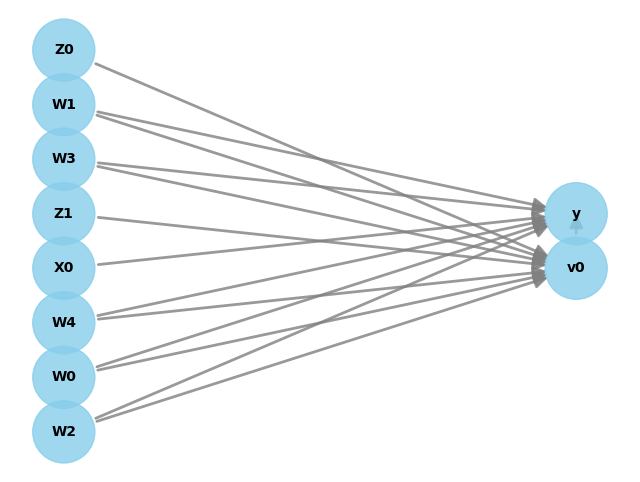

In [14]:
model.view_model()

Meaning:
- encodes arrows from common causes W* and instruments Z* into v0 and y, reflecting the assumed causal structure.
- This makes explicit which variables are treated as confounders, instruments, and effect modifiers.

# Identify the Effect

In [15]:
identified_estimand = model.identify_effect(
    proceed_when_unidentifiable=True  # allow ignoring unobserved confounding for demo
)

In [18]:
identified_estimand

In [17]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W2,W0,W4,W3,W1])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W2,W0,W4,W3,W1,U) = P(y|v0,W2,W0,W4,W3,W1)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                              -1⎤
 ⎢    d        ⎛    d          ⎞  ⎥
E⎢─────────(y)⋅⎜─────────([v₀])⎟  ⎥
 ⎣d[Z₁  Z₀]    ⎝d[Z₁  Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z1,Z0})
Estimand assumption 2, Exclusion: If we remove {Z1,Z0}→{v0}, then ¬({Z1,Z0}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                       
─────(E[y|W2,W0,W4,W3,W1])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W2,W0,W4,W3,W1,U) = P(y|v0,W2,W0,W4,W3,W1)



# Estimate the Causal Effect

In [19]:
causal_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_stratification",
)

In [20]:
causal_estimate

In [21]:
print(causal_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W2,W0,W4,W3,W1])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W2,W0,W4,W3,W1,U) = P(y|v0,W2,W0,W4,W3,W1)

## Realized estimand
b: y~v0+W2+W0+W4+W3+W1
Target units: ate

## Estimate
Mean value: 7.7765919256560005



In [22]:
# To see effect on a subgroup (e.g., controls “atc”)
estimate_atc = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_stratification",
    target_units="atc",
)

In [24]:
estimate_atc

In [23]:
print("ATC:", estimate_atc.value)

ATC: 7.870727626520726


# Run refutation tests (robustness)
These refutation outputs help interpret how trustworthy the estimate is, not just its point value.

In [25]:
# Random common cause (should not change estimate much)
res_random = model.refute_estimate(
    identified_estimand, causal_estimate,
    method_name="random_common_cause",
    show_progress_bar=True,
)
print(res_random)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:7.7765919256560005
New effect:7.776591925656003
p value:1.0



Random common cause: new effect ~7.77, 
p‑value high → estimate is stable to adding irrelevant variables.

In [26]:
# Placebo treatment (effect should be ~0)
res_placebo = model.refute_estimate(
    identified_estimand, causal_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    show_progress_bar=True,
)
print(res_placebo)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:7.7765919256560005
New effect:0.1304872366769175
p value:0.8400000000000001



Placebo treatment: new effect ≈ 0.13, 
p‑value high → estimator does not find spurious effects when treatment is random.

In [27]:
# Subset refuter (dropping random fraction of data)
res_subset = model.refute_estimate(
    identified_estimand, causal_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.9,
    show_progress_bar=True,
)
print(res_subset)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:7.7765919256560005
New effect:7.807364124362715
p value:0.72



Data subset: new effect close to original, 
p‑value high → estimate is stable to sampling variation.